<a href="https://colab.research.google.com/github/boniphacebenja78-lgtm/lab3.-Neural-Networks/blob/main/Lab_3_Neural%20Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
# lab 3_NEURAL NETWORKS, FeedForward Networks and the Training Process
# STUDENT NAME: Boniphace Benjamin Makoga
#STUDENT-ID: 75052028

In [41]:
#Standad Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

#for section 2
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)
np.random.seed(int(RANDOM_STATE))

print("Running on device:", DEVICE)

Running on device: cpu


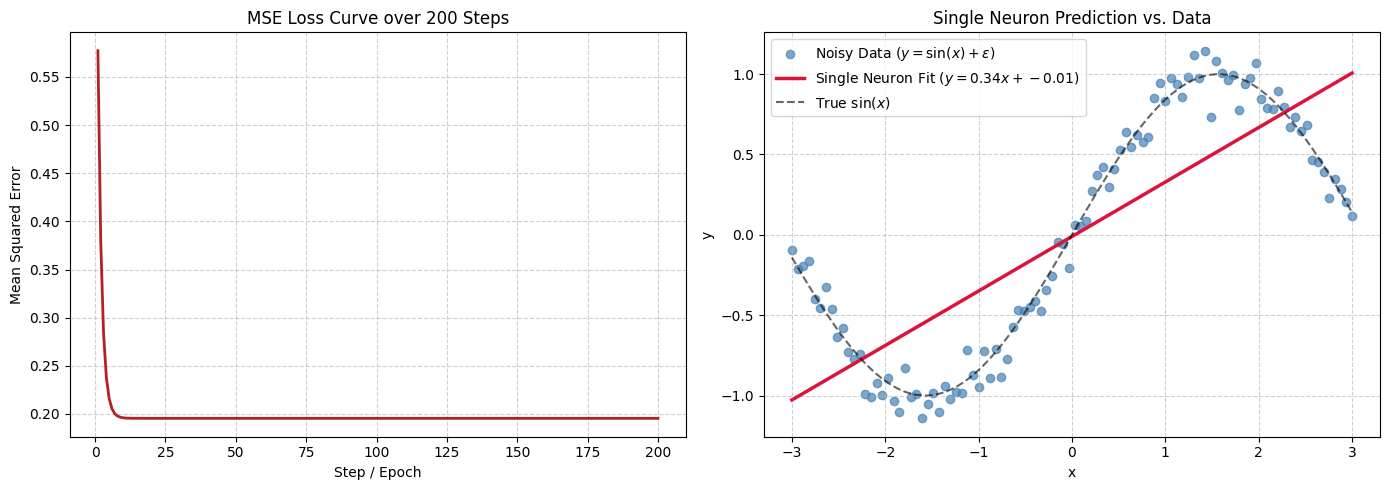

In [42]:
#Part.1.1 - Single neuron is just a line
np.random.seed(RANDOM_STATE)

#1 generate toy data:y = sin(x) + smalll Gaussian noise(Std =0.1)
x = np.linspace(-3,3,100)
noise = np.random.normal(0,0.1, size=x.shape)
y = np.sin(x) + noise

#Initializing parameter w and b
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

#hyperpareameters
learning_rate = 0.05
epochs = 200
loss_history = []

#Manual Gradient descent loop
for step in range(epochs):

    # Forward-pass: prediction and loss
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)

    # Backward-pass: manual gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Parameter update step
    w -= learning_rate * dw
    b -= learning_rate * db

#Visualization
plt.figure(figsize=(14, 5))

# Loss curve PLot
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), loss_history, color="firebrick", linewidth=2)
plt.title("MSE Loss Curve over 200 Steps")
plt.xlabel("Step / Epoch")
plt.ylabel("Mean Squared Error")
plt.grid(True, linestyle="--", alpha=0.6)

# Fitted Line vs. Ground Truth Data Plot
plt.subplot(1, 2, 2)
plt.scatter(x, y, color="steelblue", alpha=0.7, label="Noisy Data ($y = \\sin(x) + \\epsilon$)")
plt.plot(x, w * x + b, color="crimson", linewidth=2.5, label=f"Single Neuron Fit ($y = {w:.2f}x + {b:.2f}$)")
plt.plot(x, np.sin(x), color="black", linestyle="--", alpha=0.6, label="True $\\sin(x)$")
plt.title("Single Neuron Prediction vs. Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


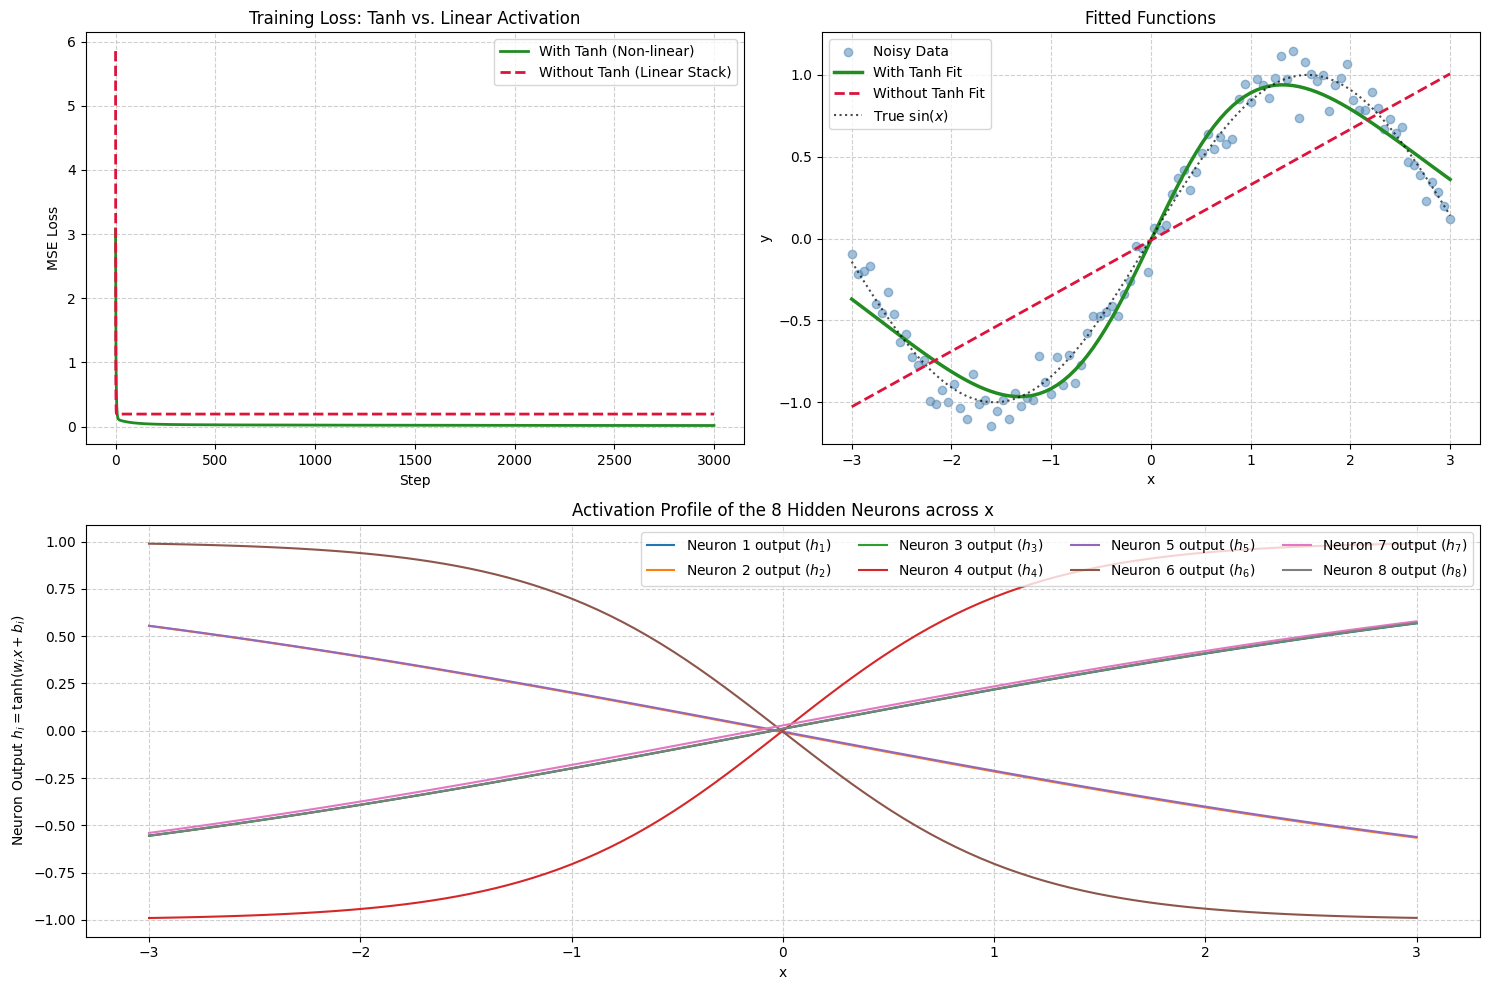

In [43]:
#Part 1.3: Hidden Layers and activation
np.random.seed(int(RANDOM_STATE))
#inputs and tagerts with column vector shapes
X_in = x.reshape (-1,1)
Y_in = y.reshape (-1,1)

#fuction to train custom Numpy network
def train_numpy_mlp(X, Y, use_tanh=True, lr=0.03, steps=3000):
    np.random.seed(int(RANDOM_STATE))

    # 1. Parameter initialization
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((1, 8))
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1, 1))

    loss_history = []

    for step in range(steps):
        # --- forward pass
        z1 = X @ W1 + b1
        h = np.tanh(z1) if use_tanh else z1
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - Y) ** 2)
        loss_history.append(loss)

        # --- backward pass
        N = len(Y)
        d_yhat = 2 * (y_hat - Y) / N

        dW2 = h.T @ d_yhat
        db2 = np.sum(d_yhat, axis=0, keepdims=True)

        dh = d_yhat @ W2.T

        # derivative of activation
        if use_tanh:
            dz1 = dh * (1 - np.tanh(z1) ** 2)
        else:
            dz1 = dh

        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Parameter Updates
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    return loss_history, y_hat,h, W1, b1, W2, b2

# train tanh
loss_with_tanh, pred_with_tanh, hidden_acts, W1, b1, W2, b2 = train_numpy_mlp(X_in, Y_in, use_tanh=True)

# Train without tanh (pure linear network)
loss_no_tanh, pred_no_tanh, _, _, _, _, _ = train_numpy_mlp(X_in, Y_in, use_tanh=False)


#VISUALIZATION
plt.figure(figsize=(15, 10))

# Loss curve PLot
plt.subplot(2, 2, 1)
plt.plot(loss_with_tanh, label="With Tanh (Non-linear)", color="forestgreen", linewidth=2)
plt.plot(loss_no_tanh, label="Without Tanh (Linear Stack)", color="crimson", linestyle="--", linewidth=2)
plt.title("Training Loss: Tanh vs. Linear Activation")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

#plot predications vs data
plt.subplot(2, 2, 2)
plt.scatter(x, y, alpha=0.5, color="steelblue", label="Noisy Data")
plt.plot(x, pred_with_tanh, color="forestgreen", linewidth=2.5, label="With Tanh Fit")
plt.plot(x, pred_no_tanh, color="crimson", linestyle="--", linewidth=2, label="Without Tanh Fit")
plt.plot(x, np.sin(x), color="black", linestyle=":", alpha=0.7, label="True $\\sin(x)$")
plt.title("Fitted Functions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

#plot visualization of hidden Neurons
plt.subplot(2, 2, (3, 4))
for i in range(8):
    plt.plot(x, hidden_acts[:, i], label=f"Neuron {i+1} output ($h_{{{i+1}}}$)")
plt.title("Activation Profile of the 8 Hidden Neurons across x")
plt.xlabel("x")
plt.ylabel("Neuron Output $h_i = \\tanh(w_i x + b_i)$")
plt.legend(ncol=4, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()








/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_2390/1579933646.py:24: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - Y) ** 2)
/tmp/ipykernel_2390/1579933646.py:34: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_2390/1579933646.py:35: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


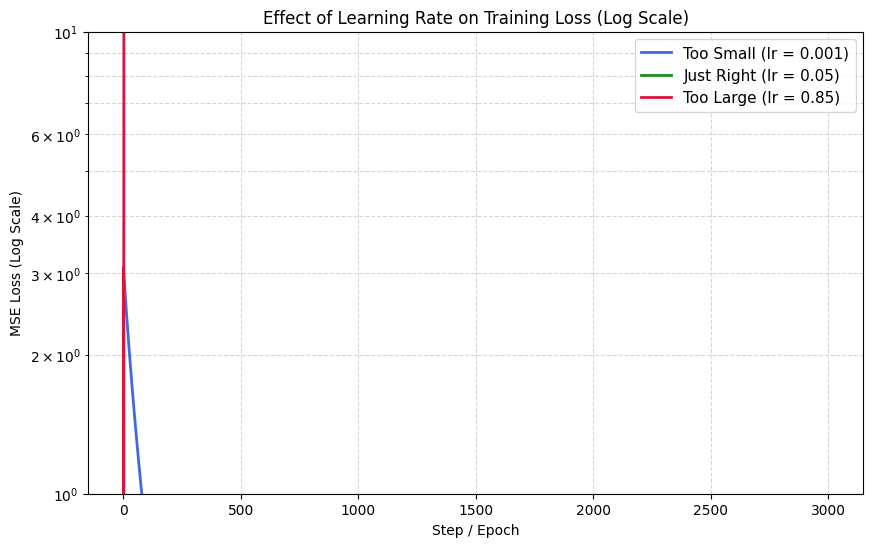

In [44]:
#Part 1.3 - The learning rate : too cold , too hot, just right

def train_toy(lr, steps=3000):
    np.random.seed(int(RANDOM_STATE))

    # Reshape inputs to 2D column vectors
    X = x.reshape(-1, 1)
    Y = y.reshape(-1, 1)

    # Initialize parameters with identical initial state
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((1, 8))
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1, 1))

    loss_history = []

    for step in range(steps):
        # Forward pass
        z1 = X @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - Y) ** 2)
        loss_history.append(loss)

        # Backward pass
        N = len(Y)
        d_yhat = 2 * (y_hat - Y) / N

        dW2 = h.T @ d_yhat
        db2 = np.sum(d_yhat, axis=0, keepdims=True)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Parameterz
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    return loss_history

# Run experiments across the three learning rate regimes
lr_small = 0.001
lr_ideal = 0.05
lr_large = 0.85

loss_small = train_toy(lr=lr_small, steps=3000)
loss_ideal = train_toy(lr=lr_ideal, steps=3000)
loss_large = train_toy(lr=lr_large, steps=3000)

# Visualization
plt.figure(figsize=(10, 6))

plt.plot(loss_small, label=f"Too Small (lr = {lr_small})", color="royalblue", linewidth=2)
plt.plot(loss_ideal, label=f"Just Right (lr = {lr_ideal})", color="forestgreen", linewidth=2)
plt.plot(loss_large, label=f"Too Large (lr = {lr_large})", color="crimson", linewidth=2)

plt.yscale("log")
plt.title("Effect of Learning Rate on Training Loss (Log Scale)")
plt.xlabel("Step / Epoch")
plt.ylabel("MSE Loss (Log Scale)")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=11)

plt.show()




In [45]:
#Section 2 - A rEAL fEEDFORWARD nETWROK IN pYTORCH


In [46]:
# Part 2.1 : Preprocessing and split

# load the obesity dataset
# Wrap the URL in quotation marks:
OBESITY_URL = "https://raw.githubusercontent.com/pymche/Machine-Learning-Obesity-Classification/master/ObesityDataSet_raw_and_data_sinthetic.csv"

try:
    df = pd.read_csv(OBESITY_URL)
    print("Dataset successfully loaded from online URL!")
except Exception as e:
    print(f"Failed to load online. Attempting local load... Error: {e}")
    df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

#encode categorical
X = df.drop(columns=["NObeyesdad"]).copy()
y_raw = df["NObeyesdad"]

# Encode target NObeyesdad into integer 0..6
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

binary_cols = ["gender", "family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in X.columns:
    if col in binary_cols or col.lower() in binary_cols:
        X[col] = X[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0}).fillna(X[col])

X_encoded = pd.get_dummies(X, drop_first=True)

#stratified / validation/ test split
#first split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded
)
#second split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train_val
)

#fit starndard scaler on training set only and transform all three splits
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#convert to pytorch and warp in dataloaders
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(X_val_scaled, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)
#create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Data successfully processed and loaded!")
print(f"Train set: {len(train_dataset)} samples ({len(train_loader)} batches)")
print(f"Val set:   {len(val_dataset)} samples ({len(val_loader)} batches)")
print(f"Test set:  {len(test_dataset)} samples ({len(test_loader)} batches)")



Dataset successfully loaded from online URL!
Data successfully processed and loaded!
Train set: 1350 samples (43 batches)
Val set:   338 samples (11 batches)
Test set:  423 samples (14 batches)


In [47]:
# Part 2.2  - DESIGN the network

#define feedforward class
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()

        # Layer 1, Input -> Hidden 1
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.relu1 = nn.ReLU()

        # Layer 2, Hidden 1 -> Hidden 2
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()

        # Layer 3, Hidden 2 -> Output Logits
        self.out = nn.Linear(hidden_sizes[1], n_classes)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.out(x)
        return x
# instantiate models
input_dim = X_train_scaled.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)

print(model)
print("-" * 50)

# trainable parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters (PyTorch): {total_params}")





FeedForwardNet(
  (fc1): Linear(in_features=23, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (out): Linear(in_features=32, out_features=7, bias=True)
)
--------------------------------------------------
Total Trainable Parameters (PyTorch): 3847


Epoch 05/60 | Train Loss: 0.7898 | Train Acc: 73.85% | Val Loss: 0.8219 | Val Acc: 71.01% -> [Saved Best Model]
Epoch 10/60 | Train Loss: 0.4027 | Train Acc: 86.96% | Val Loss: 0.5090 | Val Acc: 84.02% -> [Saved Best Model]
Epoch 15/60 | Train Loss: 0.2373 | Train Acc: 93.48% | Val Loss: 0.3872 | Val Acc: 85.50%
Epoch 20/60 | Train Loss: 0.1562 | Train Acc: 95.63% | Val Loss: 0.3060 | Val Acc: 89.64% -> [Saved Best Model]
Epoch 25/60 | Train Loss: 0.1035 | Train Acc: 97.78% | Val Loss: 0.2748 | Val Acc: 91.12%
Epoch 30/60 | Train Loss: 0.0727 | Train Acc: 99.04% | Val Loss: 0.2601 | Val Acc: 91.42%
Epoch 35/60 | Train Loss: 0.0516 | Train Acc: 99.56% | Val Loss: 0.2486 | Val Acc: 91.42%
Epoch 40/60 | Train Loss: 0.0395 | Train Acc: 99.85% | Val Loss: 0.2473 | Val Acc: 92.31%
Epoch 45/60 | Train Loss: 0.0290 | Train Acc: 99.85% | Val Loss: 0.2489 | Val Acc: 92.01%
Epoch 50/60 | Train Loss: 0.0217 | Train Acc: 99.93% | Val Loss: 0.2568 | Val Acc: 92.01%
Epoch 55/60 | Train Loss: 0.0172 |

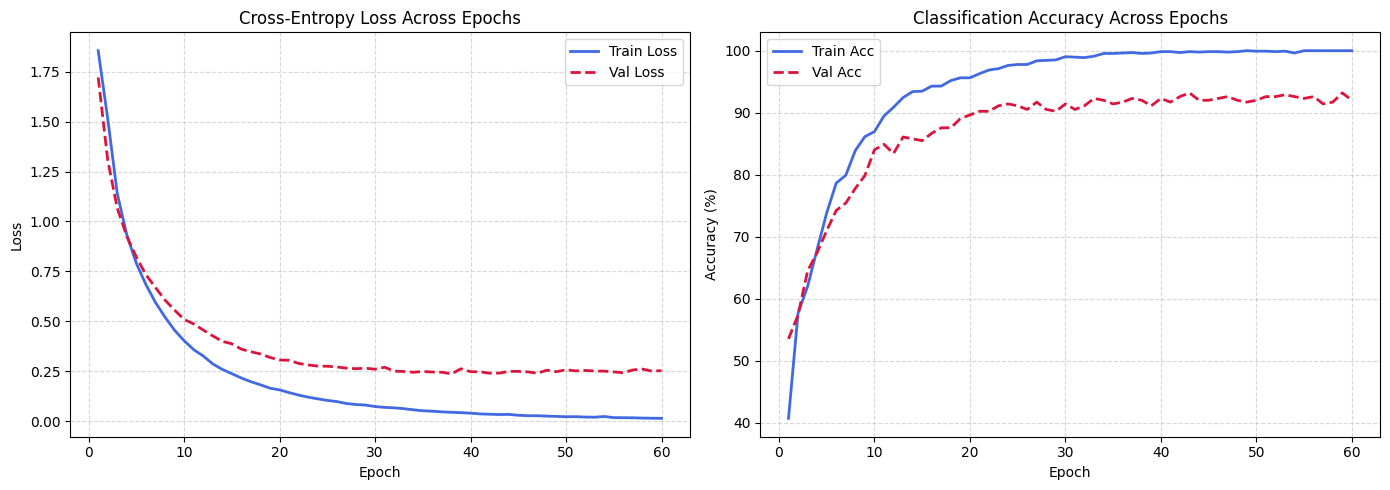

In [48]:
# Part 2.3: training loop
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 60
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc': []
}

best_val_acc = 0.0

# Training Loop
for epoch in range(1, epochs + 1):
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)
        _, preds = torch.max(logits, dim=1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)

    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train

    # validation
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)

            running_val_loss += loss.item() * xb.size(0)
            _, preds = torch.max(logits, dim=1)
            correct_val += (preds == yb).sum().item()
            total_val += yb.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val

    # Record metrics
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    # Checkpoint best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "ffn_best.pt")
        saved_str = " -> [Saved Best Model]"
    else:
        saved_str = ""

    # Print progress every 5 epochs and final epoch
    if epoch % 5 == 0 or epoch == epochs:
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%{saved_str}")

# visualization
plt.figure(figsize=(14, 5))

# Plot (a). loss curves
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
plt.plot(range(1, epochs + 1), history['val_loss'], label='Val Loss', color='crimson', linewidth=2, linestyle='--')
plt.title('Cross-Entropy Loss Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Plot (b), Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), [acc * 100 for acc in history['train_acc']], label='Train Acc', color='royalblue', linewidth=2)
plt.plot(range(1, epochs + 1), [acc * 100 for acc in history['val_acc']], label='Val Acc', color='crimson', linewidth=2, linestyle='--')
plt.title('Classification Accuracy Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



Running Experiment A (Capacity)...
Running Experiment B (Learning Rate)...
Running Experiment C (Regularization with Dropout)...


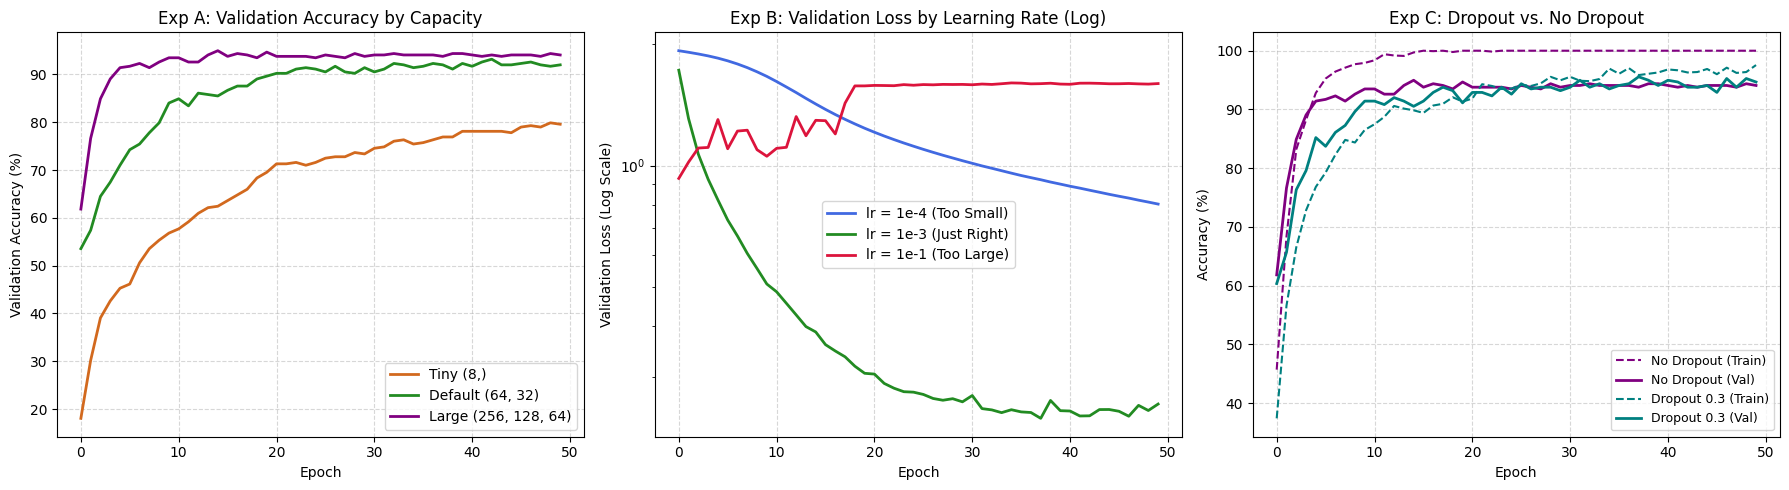

In [49]:
#PART 2.4 : Experimentsh how training choices change the outcome

class FlexibleFFN(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super(FlexibleFFN, self).__init__()
        layers = []
        in_dim = input_dim

        for h_dim in hidden_sizes:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

#experiment training function
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):

    torch.manual_seed(RANDOM_STATE)
    np.random.seed(int(RANDOM_STATE))

    # DataLoaders with custom batch size
    train_ldr = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_ldr = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    input_dim = X_train_scaled.shape[1]
    exp_model = FlexibleFFN(input_dim, hidden_sizes, n_classes=7, dropout=dropout).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(exp_model.parameters(), lr=lr)

    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # Training
        exp_model.train()
        running_t_loss, correct_t, total_t = 0.0, 0, 0
        for xb, yb in train_ldr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = exp_model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_t_loss += loss.item() * xb.size(0)
            _, preds = torch.max(logits, dim=1)
            correct_t += (preds == yb).sum().item()
            total_t += yb.size(0)

        # Validation
        exp_model.eval()
        running_v_loss, correct_v, total_v = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_ldr:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = exp_model(xb)
                loss = criterion(logits, yb)

                running_v_loss += loss.item() * xb.size(0)
                _, preds = torch.max(logits, dim=1)
                correct_v += (preds == yb).sum().item()
                total_v += yb.size(0)

        hist['train_loss'].append(running_t_loss / total_t)
        hist['val_loss'].append(running_v_loss / total_v)
        hist['train_acc'].append(correct_t / total_t)
        hist['val_acc'].append(correct_v / total_v)

    return hist

# experiments execution
print("Running Experiment A (Capacity)...")
hist_tiny  = run_experiment(hidden_sizes=(8,),         epochs=50)
hist_def   = run_experiment(hidden_sizes=(64, 32),     epochs=50)
hist_large = run_experiment(hidden_sizes=(256, 128, 64), epochs=50)

#plotting
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot([acc * 100 for acc in hist_tiny['val_acc']],  label="Tiny (8,)", color="chocolate", linewidth=2)
plt.plot([acc * 100 for acc in hist_def['val_acc']],   label="Default (64, 32)", color="forestgreen", linewidth=2)
plt.plot([acc * 100 for acc in hist_large['val_acc']], label="Large (256, 128, 64)", color="purple", linewidth=2)
plt.title("Exp A: Validation Accuracy by Capacity")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)


print("Running Experiment B (Learning Rate)...")
hist_lr_low  = run_experiment(lr=1e-4, epochs=50)
hist_lr_mid  = run_experiment(lr=1e-3, epochs=50)
hist_lr_high = run_experiment(lr=1e-1, epochs=50)

#plottting
plt.subplot(1, 3, 2)
plt.plot(hist_lr_low['val_loss'],  label="lr = 1e-4 (Too Small)", color="royalblue", linewidth=2)
plt.plot(hist_lr_mid['val_loss'],  label="lr = 1e-3 (Just Right)", color="forestgreen", linewidth=2)
plt.plot(hist_lr_high['val_loss'], label="lr = 1e-1 (Too Large)", color="crimson", linewidth=2)
plt.yscale("log")
plt.title("Exp B: Validation Loss by Learning Rate (Log)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss (Log Scale)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)


print("Running Experiment C (Regularization with Dropout)...")
hist_no_drop   = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0, epochs=50)
hist_with_drop = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3, epochs=50)

#plotting
plt.subplot(1, 3, 3)
plt.plot([acc * 100 for acc in hist_no_drop['train_acc']], label="No Dropout (Train)", color="purple", linestyle="--")
plt.plot([acc * 100 for acc in hist_no_drop['val_acc']],   label="No Dropout (Val)", color="purple", linewidth=2)
plt.plot([acc * 100 for acc in hist_with_drop['train_acc']], label="Dropout 0.3 (Train)", color="teal", linestyle="--")
plt.plot([acc * 100 for acc in hist_with_drop['val_acc']],   label="Dropout 0.3 (Val)", color="teal", linewidth=2)
plt.title("Exp C: Dropout vs. No Dropout")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend(fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()





--------------------------------------------------
Neural Network Test Accuracy: 92.20%
Neural Network Test Macro-F1: 0.9200
--------------------------------------------------
Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.96      0.96        54
      Normal_Weight       0.83      0.86      0.85        58
     Obesity_Type_I       0.92      0.99      0.95        70
    Obesity_Type_II       0.98      0.95      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.84      0.83      0.83        58
Overweight_Level_II       0.91      0.86      0.88        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.92      0.92      0.92       423



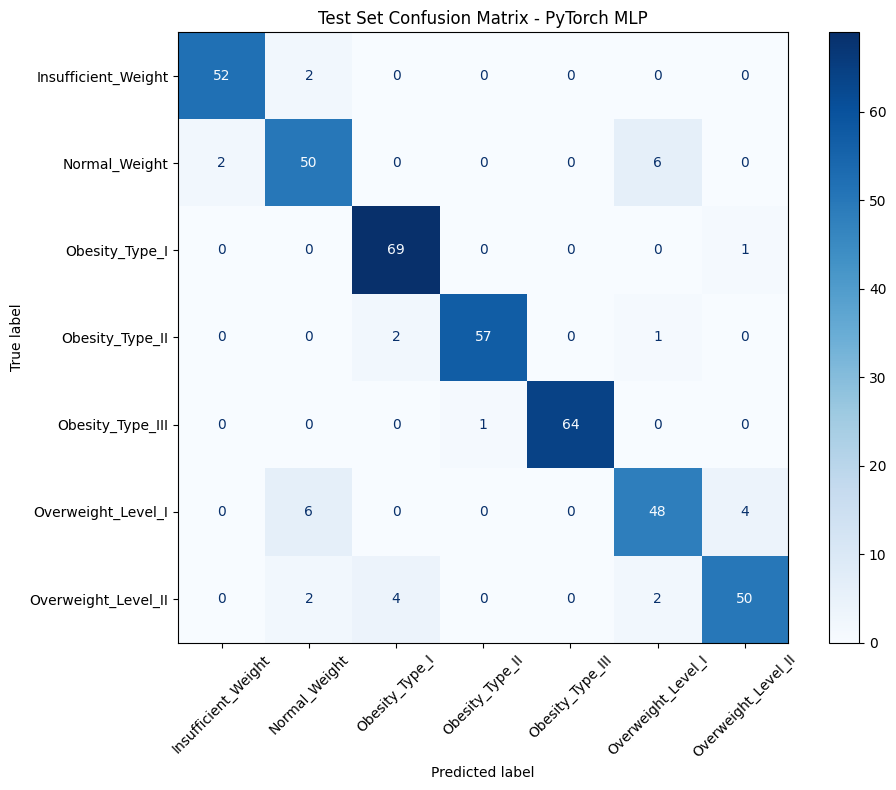

In [50]:
#Part 2.5: final evaluation

#best configuration weights
best_model = FeedForwardNet(input_dim=X_train_scaled.shape[1], hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
best_model.load_state_dict(torch.load("ffn_best.pt", weights_only=True))
best_model.eval()

#test set
all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        _, preds = torch.max(logits, dim=1)

        # Move back to CPU for Scikit-Learn metrics
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(yb.numpy())

#compute metrics
test_acc = accuracy_score(all_targets, all_preds)
test_f1 = f1_score(all_targets, all_preds, average='macro')

print("-" * 50)
print(f"Neural Network Test Accuracy: {test_acc*100:.2f}%")
print(f"Neural Network Test Macro-F1: {test_f1:.4f}")
print("-" * 50)
print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=label_encoder.classes_))

#confusion matric plot
cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Test Set Confusion Matrix - PyTorch MLP")
plt.tight_layout()
plt.show()



